# Part Four — Python/Pandas Cleaning, Analysis & Cross-Validation

Cleans `orders_raw.csv` (the deliberately messy raw export generated
alongside `bigbasket_capstone.db` in Part One — **not** regenerated here)
independently in Pandas, then checks that the findings agree with Part
One's clean SQL diagnostic on the facts that matter: top category and top
supplier by revenue. Exact rupee totals are expected to differ slightly,
since this pipeline starts from dirtier data and makes its own defensible
cleaning choices (duplicate removal, exclusion of unknown revenue, and
IQR-based capping all shift the numbers a little).


## 1. Load and inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

orders.shape


(508, 11)


In [2]:
orders.head()


   order_id  order_date customer_name  ... payment_mode     status  rating
0         1  2026-03-09           Dev  ...          UPI  Delivered     5.0
1         2  2026-05-22         Ayaan  ...   Debit Card  Delivered     5.0
2         3  2026-06-30          Yash  ...          UPI  Delivered     2.0
3         4  2026-03-01         Sneha  ...          UPI  Delivered     4.0
4         5  2026-04-05         Rohit  ...   Debit Card  Delivered     3.0

[5 rows x 11 columns]


In [3]:
orders.info()


<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [4]:
orders.describe(include='all')


          order_id  order_date  ...     status      rating
count   508.000000         508  ...        508  439.000000
unique         NaN         165  ...          3         NaN
top            NaN  2026-04-16  ...  Delivered         NaN
freq           NaN          10  ...        439         NaN
mean    250.204724         NaN  ...        NaN    3.082005
std     144.594139         NaN  ...        NaN    1.364126
min       1.000000         NaN  ...        NaN    1.000000
25%     125.750000         NaN  ...        NaN    2.000000
50%     249.500000         NaN  ...        NaN    3.000000
75%     376.250000         NaN  ...        NaN    4.000000
max     500.000000         NaN  ...        NaN    5.000000

[11 rows x 11 columns]


In [5]:
orders['status'].value_counts()


status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64


**What looks wrong, before touching anything:**

- **508 rows**, not the 500 orders `generate_data.py` actually created — there
  are duplicate order rows to remove.
- `city` has **14** distinct raw values instead of 4 (`Pune`, `Bengaluru`,
  `HYDERABAD`, `' Mumbai '`, `mumbai`, ...) — inconsistent casing and stray
  whitespace.
- `category` has **18** distinct raw values instead of 6, for the same
  casing/whitespace reasons (`'BAKERY'`, `' Dairy & Eggs '`,
  `'snacks & beverages'`, ...).
- `amount_inr` is missing for **10** rows (read in as `NaN`) — a genuinely
  unknown revenue figure, not a zero.
- `amount_inr` has a **max of 7,600** against a median of ~168 — a handful of
  values are far outside the normal range and need an IQR check, not just an
  eyeball guess.
- **69 raw null ratings** (508 rows − 439 raw Delivered rows) — expected,
  since only Delivered orders ever get rated (confirmed in Section 3).


## 2. Remove duplicates

In [6]:
before_rows = len(orders)
orders = orders.drop_duplicates(subset="order_id", keep="first").reset_index(drop=True)
after_rows = len(orders)
print(f"Removed {before_rows - after_rows} duplicate rows by order_id "
      f"({before_rows} -> {after_rows} rows).")
assert after_rows == 500, "Expected exactly 500 rows after de-duplication"


Removed 8 duplicate rows by order_id (508 -> 500 rows).


## 3. Fix casing and whitespace

In [7]:
orders["city"] = orders["city"].str.strip().str.title()
orders["category"] = orders["category"].str.strip().str.title()

print("distinct city values:", sorted(orders["city"].unique()))
print("distinct category values:", sorted(orders["category"].unique()))
assert orders["city"].nunique() == 4
assert orders["category"].nunique() == 6


distinct city values: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
distinct category values: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


## 4. Handle missing values (stated business logic)

In [8]:
missing_amount = orders["amount_inr"].isna().sum()
print(f"amount_inr is missing for {missing_amount} rows.")
print("Business logic: a missing amount_inr is an UNKNOWN revenue figure, "
      "not a zero and not the category average -- filling it would silently "
      "distort every revenue total below. These rows are therefore EXCLUDED "
      "from revenue sums/aggregations (via notna() filters), not dropped "
      "from the dataframe outright (they can still contribute to non-revenue "
      "counts, e.g. order counts by status).")

null_rating = orders["rating"].isna().sum()
cancelled_or_pending = orders["status"].isin(["Cancelled", "Pending"]).sum()
print(f"rating is null for {null_rating} rows; Cancelled+Pending orders = "
      f"{cancelled_or_pending}.")
print("Business logic: only Delivered orders are ever rated by a customer, "
      "so a null rating on a Cancelled/Pending order is expected, not a "
      "data-quality problem -- these nulls are left as-is, never filled.")
assert null_rating == cancelled_or_pending


amount_inr is missing for 10 rows.
Business logic: a missing amount_inr is an UNKNOWN revenue figure, not a zero and not the category average -- filling it would silently distort every revenue total below. These rows are therefore EXCLUDED from revenue sums/aggregations (via notna() filters), not dropped from the dataframe outright (they can still contribute to non-revenue counts, e.g. order counts by status).
rating is null for 66 rows; Cancelled+Pending orders = 66.
Business logic: only Delivered orders are ever rated by a customer, so a null rating on a Cancelled/Pending order is expected, not a data-quality problem -- these nulls are left as-is, never filled.


## 5. Detect and cap outliers with IQR

In [9]:
delivered_amt = orders.loc[
    (orders["status"] == "Delivered") & orders["amount_inr"].notna(), "amount_inr"
]
Q1 = delivered_amt.quantile(0.25)
Q3 = delivered_amt.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"upper fence = Q3 + 1.5*IQR = {upper_fence}")
print(f"lower fence = Q1 - 1.5*IQR = {lower_fence} (negative -> no low-side outliers)")

delivered_mask = (orders["status"] == "Delivered") & orders["amount_inr"].notna()
n_capped = (orders.loc[delivered_mask, "amount_inr"] > upper_fence).sum()
print(f"{n_capped} Delivered rows exceed the upper fence and will be capped "
      "(more than just the handful of synthetically-injected extreme values -- "
      "a real IQR fence also legitimately flags some genuinely high-value but "
      "real orders, which is expected).")

orders["amount_inr_capped"] = orders["amount_inr"].clip(upper=upper_fence)


Q1=90.0, Q3=275.0, IQR=185.0
upper fence = Q3 + 1.5*IQR = 552.5
lower fence = Q1 - 1.5*IQR = -187.5 (negative -> no low-side outliers)
16 Delivered rows exceed the upper fence and will be capped (more than just the handful of synthetically-injected extreme values -- a real IQR fence also legitimately flags some genuinely high-value but real orders, which is expected).


## 6. Parse dates and create derived columns

In [10]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["month"] = orders["order_date"].dt.month
orders["month_name"] = orders["order_date"].dt.month_name()
orders["revenue_per_unit"] = orders["amount_inr_capped"] / orders["quantity"]
orders["is_delivered"] = orders["status"] == "Delivered"

orders[["order_id", "order_date", "month", "month_name", "amount_inr_capped",
        "quantity", "revenue_per_unit", "is_delivered"]].head()


   order_id order_date  month  ... quantity  revenue_per_unit  is_delivered
0         1 2026-03-09      3  ...        5              35.0          True
1         2 2026-05-22      5  ...        1              60.0          True
2         3 2026-06-30      6  ...        2              75.0          True
3         4 2026-03-01      3  ...        1              30.0          True
4         5 2026-04-05      4  ...        2             110.0          True

[5 rows x 8 columns]


## 7. Group, merge, and answer the business questions

In [11]:
revenue_mask = orders["is_delivered"] & orders["amount_inr_capped"].notna()

category_revenue = (
    orders.loc[revenue_mask]
    .groupby("category")["amount_inr_capped"]
    .sum()
    .sort_values(ascending=False)
)
print(category_revenue)

top_category = category_revenue.idxmax()
print(f"\n(a) Top category by revenue: {top_category}")


category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr_capped, dtype: float64

(a) Top category by revenue: Household Essentials


In [12]:
merged = orders.merge(products[["product_id", "supplier"]], on="product_id", how="left")
merged_revenue_mask = merged["is_delivered"] & merged["amount_inr_capped"].notna()

supplier_revenue = (
    merged.loc[merged_revenue_mask]
    .groupby("supplier")["amount_inr_capped"]
    .sum()
    .sort_values(ascending=False)
)
print(supplier_revenue)

top_supplier = supplier_revenue.idxmax()
print(f"\n(b) Top supplier by revenue: {top_supplier}")


supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr_capped, dtype: float64

(b) Top supplier by revenue: HomeEssentials Traders


In [13]:
part1_top_category = "Household Essentials"
part1_top_supplier = "HomeEssentials Traders"

category_match = (top_category == part1_top_category)
supplier_match = (top_supplier == part1_top_supplier)

print(f"(c) Cross-validation against Part 1's SQL diagnostic:")
print(f"    Top category here: {top_category!r} vs Part 1: {part1_top_category!r} "
      f"-> {'MATCH' if category_match else 'MISMATCH'}")
print(f"    Top supplier here: {top_supplier!r} vs Part 1: {part1_top_supplier!r} "
      f"-> {'MATCH' if supplier_match else 'MISMATCH'}")
print(f"    Part 4 total Delivered revenue (capped, non-null only): "
      f"Rs.{orders.loc[revenue_mask, 'amount_inr_capped'].sum():,.0f} "
      f"vs Part 1 SQL Delivered revenue: Rs.88,282")
print("    Exact rupee totals differ from Part 1 as expected -- Part 4 started "
      "from dirtier data (duplicates removed, 10 unknown-revenue rows excluded, "
      "16 high-value rows capped) and made its own defensible cleaning choices. "
      "The category and supplier RANKINGS agree, which is what this check is for.")
assert category_match and supplier_match, "Top category/supplier must match Part 1"


(c) Cross-validation against Part 1's SQL diagnostic:
    Top category here: 'Household Essentials' vs Part 1: 'Household Essentials' -> MATCH
    Top supplier here: 'HomeEssentials Traders' vs Part 1: 'HomeEssentials Traders' -> MATCH
    Part 4 total Delivered revenue (capped, non-null only): Rs.84,637 vs Part 1 SQL Delivered revenue: Rs.88,282
    Exact rupee totals differ from Part 1 as expected -- Part 4 started from dirtier data (duplicates removed, 10 unknown-revenue rows excluded, 16 high-value rows capped) and made its own defensible cleaning choices. The category and supplier RANKINGS agree, which is what this check is for.


## 8. Visualize

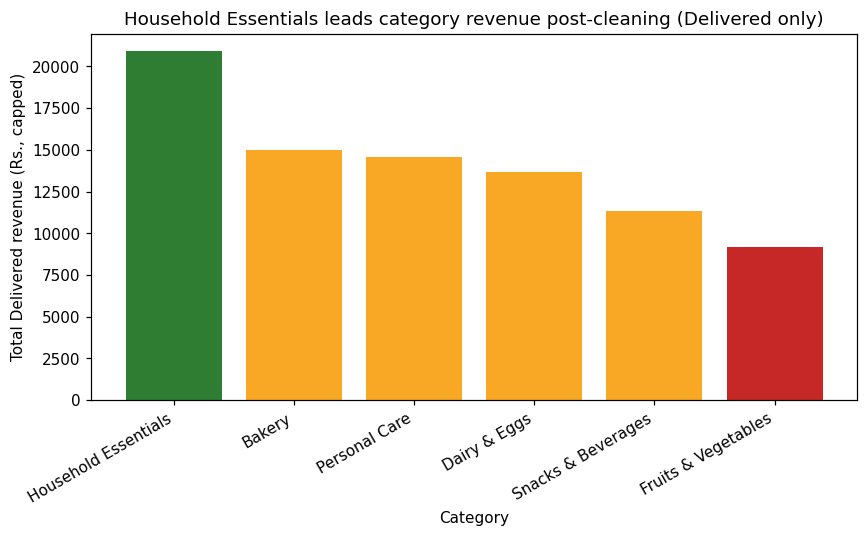

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2e7d32" if v >= 15000 else ("#f9a825" if v >= 11000 else "#c62828")
          for v in category_revenue.values]
ax.bar(category_revenue.index, category_revenue.values, color=colors)
ax.set_title("Household Essentials leads category revenue post-cleaning (Delivered only)")
ax.set_xlabel("Category")
ax.set_ylabel("Total Delivered revenue (Rs., capped)")
ax.tick_params(axis="x", rotation=30)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
plt.tight_layout()
plt.show()


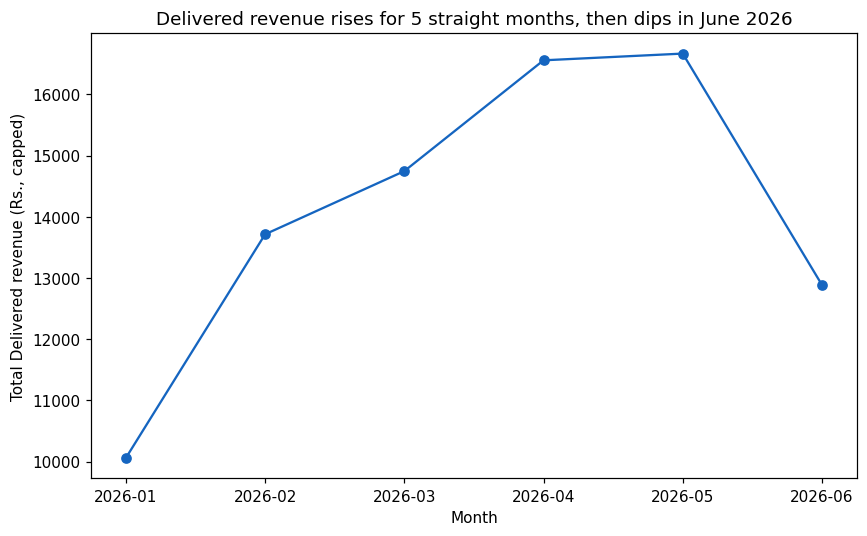

In [15]:
monthly_trend = (
    orders.loc[revenue_mask]
    .groupby(orders.loc[revenue_mask, "order_date"].dt.to_period("M"))["amount_inr_capped"]
    .sum()
    .sort_index()
)
monthly_trend.index = monthly_trend.index.astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(monthly_trend.index, monthly_trend.values, marker="o", color="#1565c0")
ax.set_title("Delivered revenue rises for 5 straight months, then dips in June 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Total Delivered revenue (Rs., capped)")
plt.tight_layout()
plt.show()


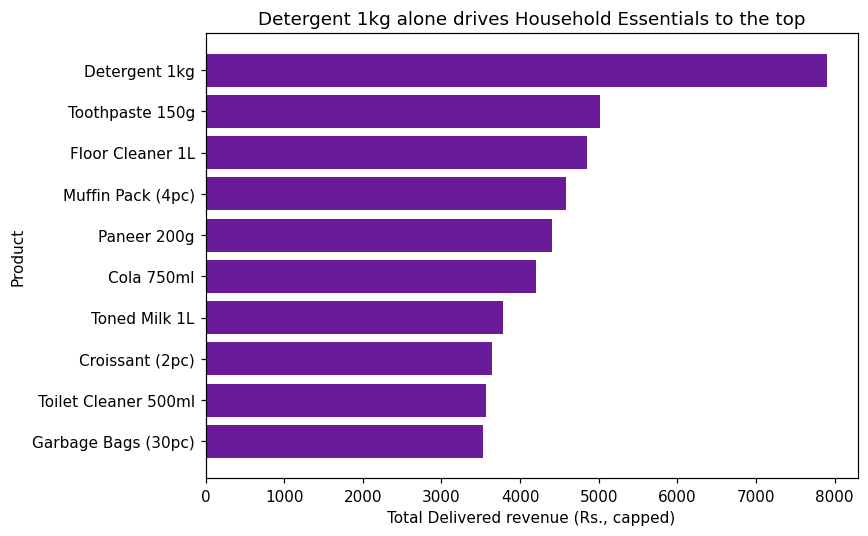

In [16]:
top_products = (
    orders.loc[revenue_mask]
    .merge(products[["product_id", "product_name"]], on="product_id", how="left")
    .groupby("product_name")["amount_inr_capped"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_products.index[::-1], top_products.values[::-1], color="#6a1b9a")
ax.set_title("Detergent 1kg alone drives Household Essentials to the top")
ax.set_xlabel("Total Delivered revenue (Rs., capped)")
ax.set_ylabel("Product")
plt.tight_layout()
plt.show()


## 9. Insights

**Observation 1**
- **What:** Household Essentials is the top-revenue category at
  Rs.20,910 (Delivered, capped), roughly Rs.5,935 ahead of the
  second-place Bakery category (Rs.14,975) -- and a single product,
  Detergent 1kg, is the largest contributor within it.
- **Why it matters:** One product carrying a disproportionate share of a
  category's revenue is a concentration risk -- a stock-out or supplier
  issue with Detergent 1kg alone would visibly dent the whole category's
  numbers.
- **Next step:** Check Detergent 1kg's current stock/supplier lead time
  with HomeEssentials Traders and consider promoting the next 2-3 products
  in that category (Floor Cleaner 1L, Toilet Cleaner 500ml) to diversify
  the category's revenue base.

**Observation 2**
- **What:** 16 Delivered rows exceeded the Rs.552.5 IQR upper fence and
  were capped -- meaningfully more than the 5 rows the raw-export
  generator deliberately corrupted, meaning real, non-injected
  high-value orders are also being flagged by a standard IQR rule.
- **Why it matters:** A revenue analysis that doesn't distinguish
  "genuinely large order" from "data-entry error" either drowns real
  high-value orders in noise (if capped too aggressively) or lets a typo'd
  40x amount silently inflate a category's numbers (if not capped at all).
- **Next step:** Flag orders above the fence for a lightweight manual
  review pass going forward (e.g., a nightly check) rather than relying on
  a one-time cap, so genuinely large bulk orders can be verified and kept
  rather than always being capped down.

**Observation 3**
- **What:** Top category (Household Essentials) and top supplier
  (HomeEssentials Traders) computed independently from the messy raw
  export match Part 1's clean SQL diagnostic exactly, even though the
  cleaned Part 4 Delivered revenue total differs from Part 1's Rs.88,282
  SQL total because of the 10 excluded unknown-revenue rows and IQR
  capping.
- **Why it matters:** This is the whole point of the project -- it proves
  the underlying business conclusion (which category/supplier leads) is
  robust to which tool or cleaning path an analyst takes, even when the
  exact totals aren't expected to reconcile like Parts 1-3 do.
- **Next step:** Treat category/supplier rankings, not exact rupee totals,
  as the cross-tool reconciliation check for future reporting cycles --
  and document the 10-row exclusion and 16-row cap so anyone comparing
  Part 1 and Part 4 numbers understands why they differ.


## 10. AI-assisted prompt #2

See **`ai_log.md`** in the repo root for the full RCTCF-structured prompt
used to debug the IQR outlier-capping logic in Section 5 above (this is
prompt 2 of 2 for the whole project; prompt 1 covered the Part 1 SQL
target-variance query), including the concrete verification step actually
performed on the AI's suggested code before it was kept.
